In [37]:
import numpy as py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [64]:
df = pd.read_csv('D:\PSL Project Data Analysis and Visualization\Dataset\psl2024.csv')
df.head()

,team1,team2,winner,margin,ground,match Date,match_id,stage
0,Qalandars,United,United,8 wickets,Lahore,2/17/2024,m_01,Group
1,Sultans,Kings,Sultans,55 runs,Multan,2/18/2024,m_02,Group
2,Zalmi,Gladiators,Gladiators,16 runs,Lahore,2/18/2024,m_03,Group
3,Qalandars,Gladiators,Gladiators,5 wickets,Lahore,2/19/2024,m_04,Group
4,Sultans,United,Sultans,5 wickets,Multan,2/20/2024,m_05,Group


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   team1       32 non-null     object
 1   team2       32 non-null     object
 2   winner      32 non-null     object
 3   margin      32 non-null     object
 4   ground      32 non-null     object
 5   match Date  32 non-null     object
 6   match_id    32 non-null     object
 7   stage       32 non-null     object
dtypes: object(8)
memory usage: 2.1+ KB


In [66]:
print(f"your rows are {df.shape[0]} and your columns are {df.shape[1]}")

your rows are 32 and your columns are 8


Data Cleaning

In [67]:
df.isnull().sum()

team1         0
team2         0
winner        0
margin        0
ground        0
match Date    0
match_id      0
stage         0
dtype: int64

In [68]:
df.columns

Index(['team1', 'team2', 'winner', 'margin', 'ground', 'match Date',
       'match_id', 'stage'],
      dtype='object')

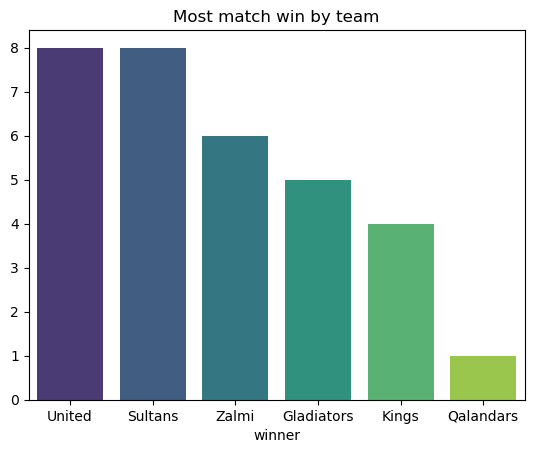

In [79]:
# Which team win the most matches?
match_wins = df['winner'].value_counts()
sns.barplot(x = match_wins.index, y = match_wins.values, palette = "viridis")
plt.title("Most match win by team")
plt.savefig("D:\PSL Project Data Analysis and Visualization\images/team_wins.png")


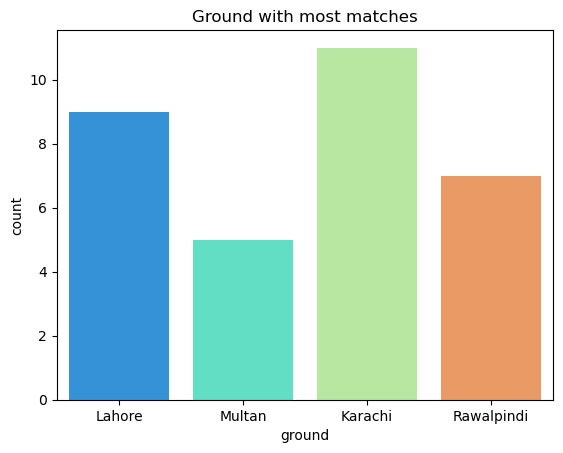

In [80]:
# Which ground hosted the most matches?
sns.countplot(x='ground', data = df, palette = "rainbow")
plt.title("Ground with most matches")
plt.savefig("D:\PSL Project Data Analysis and Visualization\images/most_mstches.png")


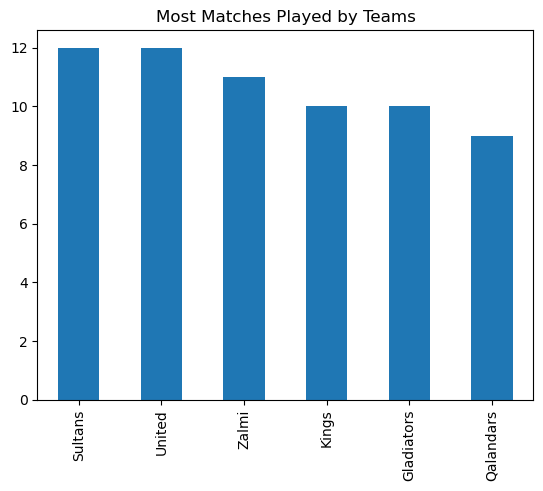

In [81]:
# Which team played most matches?
teams = pd.concat([df['team1'], df['team2']])
teams.value_counts().plot(kind = 'bar')
plt.title("Most Matches Played by Teams")
plt.savefig("D:\PSL Project Data Analysis and Visualization\images/most_match_played_by_teams.png")



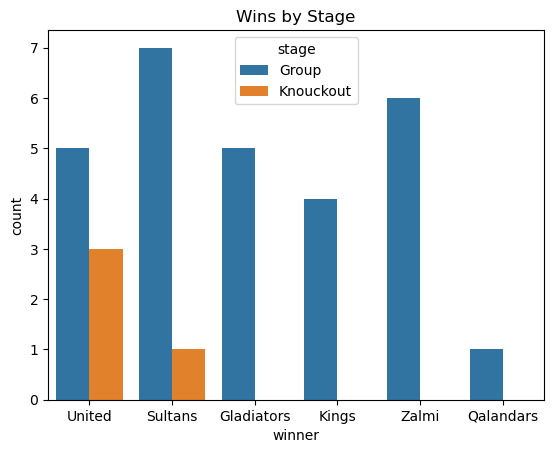

In [82]:
# Which team perform best in group stage? 
sns.countplot(x = 'winner', hue = 'stage', data=df)
plt.title("Wins by Stage")
plt.savefig("D:\PSL Project Data Analysis and Visualization\images/win_by_stage.png")


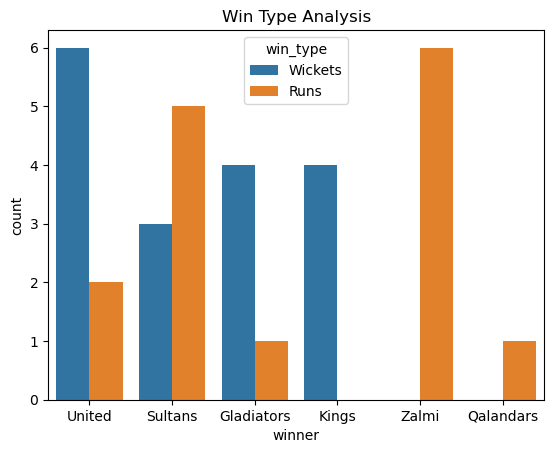

In [83]:
# Toss-Free Match Dominance
df['win_type'] = df['margin'].apply(lambda x: 'Runs' if 'runs' in x else 'Wickets')

sns.countplot(x='winner', hue='win_type', data=df)
plt.title("Win Type Analysis")

plt.savefig("D:\PSL Project Data Analysis and Visualization\images/win_type.png")


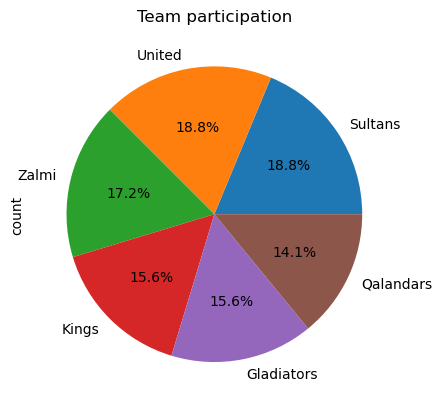

In [84]:
# Which Team Reached Most Matches?
all_teams = pd.concat([df['team1'], df['team2']])

all_teams.value_counts().plot(kind = 'pie' ,autopct='%1.1f%%')
plt.title("Team participation")
plt.savefig("D:\PSL Project Data Analysis and Visualization\images/team_participation.png")



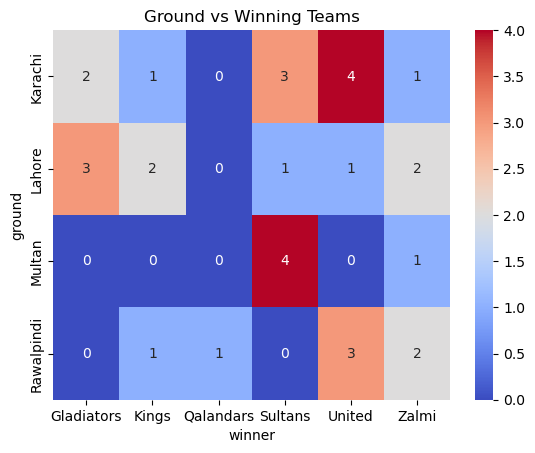

In [85]:
# Ground Wise Winning Teams
heatmap_data = pd.crosstab(df['ground'], df['winner'])

sns.heatmap(heatmap_data, annot=True, cmap='coolwarm')

plt.title("Ground vs Winning Teams")
plt.savefig("D:\PSL Project Data Analysis and Visualization\images/groundvsWinning_teams.png")


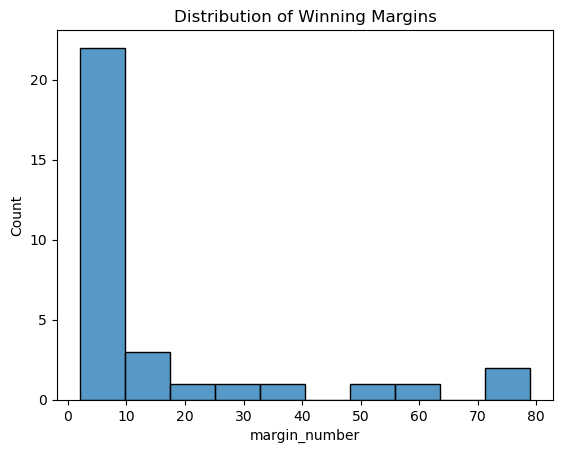

In [86]:
# Closest Matches vs Dominating Matches
df['margin_number'] = df['margin'].str.extract('(\d+)').astype(int)

sns.histplot(df['margin_number'], bins=10)

plt.title("Distribution of Winning Margins")
plt.savefig("D:\PSL Project Data Analysis and Visualization\images/ClosestvsDominating.png")


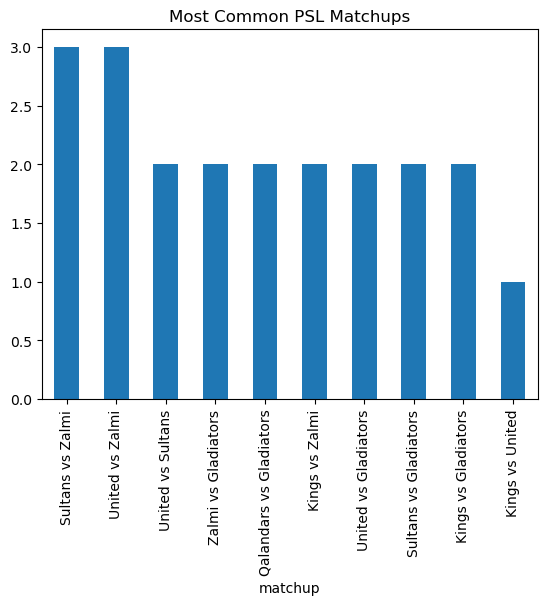

In [87]:
# Most common PSL Matchups
df['matchup'] = df['team1'] + " vs " + df['team2']
df['matchup'].value_counts().head(10).plot(kind="bar")
plt.title("Most Common PSL Matchups")
plt.savefig("D:\PSL Project Data Analysis and Visualization\images/common_psl_matchups.png")


In [78]:
# Win Percentage
wins = df['winner'].value_counts()

matches = pd.concat([df['team1'], df['team2']]).value_counts()

wins_percentage = (wins / matches) * 100

print(wins_percentage)

Gladiators    50.000000
Kings         40.000000
Qalandars     11.111111
Sultans       66.666667
United        66.666667
Zalmi         54.545455
Name: count, dtype: float64
